# Worksheet 5: End-to-End CNN for Image Classification
**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Student Name:** Suprim Shrestha  
**Student ID:** 2418110


## Task 1: Data Understanding and Visualization

In [11]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")
print(os.listdir(extract_path))

Unzipped successfully
['FruitinAmazon']


In [14]:
print(os.listdir("/content/dataset"))

['FruitinAmazon']


In [15]:
train_dir = "/content/dataset/FruitinAmazon/train"

In [16]:
print(os.listdir("/content/dataset/FruitinAmazon"))

['train', 'test']


In [17]:
print(os.listdir(train_dir))

['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


In [18]:
import os
import random
import math
import matplotlib.pyplot as plt
from PIL import Image

In [19]:
train_dir = "/content/dataset/FruitinAmazon/train"

In [20]:
classes = sorted(os.listdir(train_dir))
print("Classes found:", classes)
print("Number of classes:", len(classes))

Classes found: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [21]:
sample_images = []
sample_labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)

        if len(image_files) > 0:
            chosen_image = random.choice(image_files)
            image_path = os.path.join(class_path, chosen_image)

            sample_images.append(image_path)
            sample_labels.append(cls)

print("Total sampled images:", len(sample_images))

Total sampled images: 6


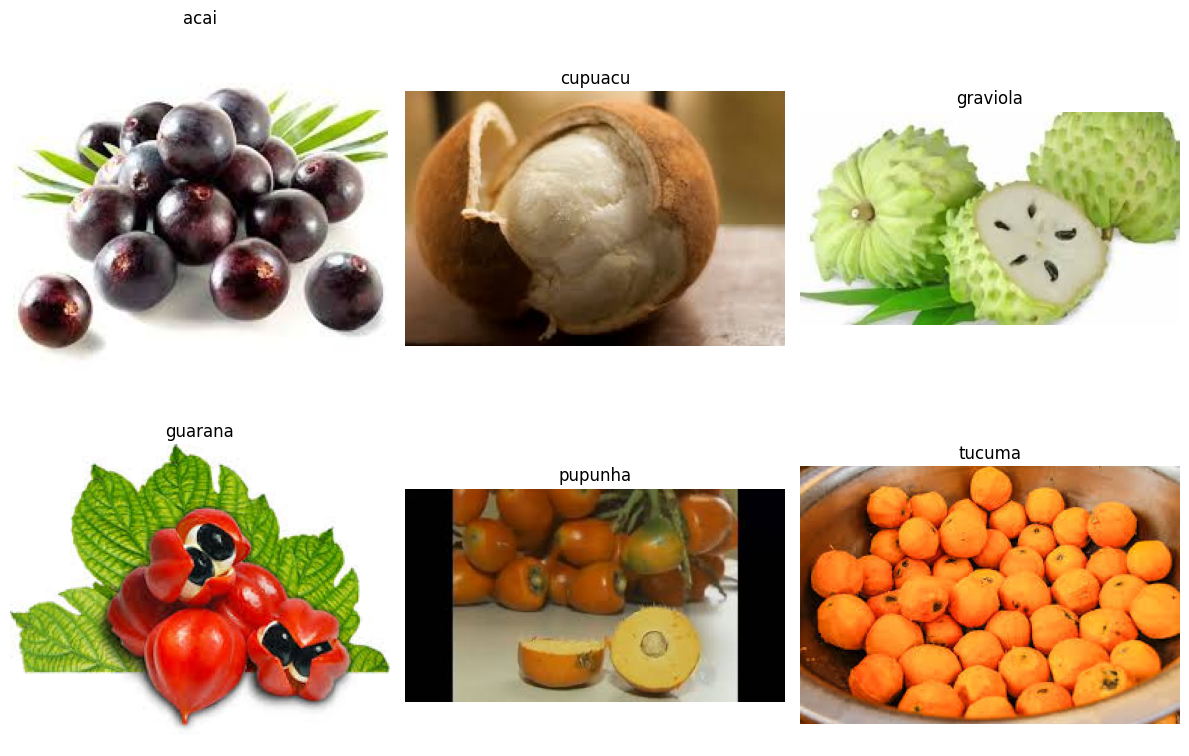

In [22]:
num_images = len(sample_images)
cols = math.ceil(num_images / 2)

plt.figure(figsize=(4 * cols, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(sample_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation
The dataset contains multiple fruit classes stored in separate folders. Each class shows distinct visual features such as color, shape, and texture. Some variations in background and lighting are observed, which makes CNN suitable for feature extraction.

## Task 1 (Part 2): Corrupted Image Detection

In [23]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found")
else:
    print("Total corrupted images removed:", len(corrupted_images))

No Corrupted Images Found


## Task 2: Loading and Preprocessing Image Data

In [24]:
import tensorflow as tf
import numpy as np

In [25]:
train_dir = "/content/dataset/FruitinAmazon/train"
test_dir = "/content/dataset/FruitinAmazon/test"

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2

In [26]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=123
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


In [27]:
class_names = train_ds.class_names
print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [28]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

###Task3: Implement CNN Architecture


In [29]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(len(class_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

7. Task 4: Model Compilation

In [30]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [32]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.1299 - loss: 2.3049
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 372ms/step - accuracy: 0.1806 - loss: 2.2483 - val_accuracy: 0.0000e+00 - val_loss: 1.4781
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.3274 - loss: 1.7604
Epoch 2: val_accuracy improved from 0.00000 to 0.44444, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 331ms/step - accuracy: 0.4028 - loss: 1.6918 - val_accuracy: 0.4444 - val_loss: 1.4457
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.3878 - loss: 1.4945
Epoch 3: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.4444 - loss: 1.4123 - val_accuracy: 0.4444 - val_loss: 1.3579
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.5840 - loss: 1.1418
Epoch 4: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 338ms/step - accuracy: 0.5972 - loss: 1.1407 - val_accuracy: 0.2778 - val_loss: 1.3121
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8271 - loss: 0.8122
Epoch 5: val_accuracy improved from 0.44444 to 0.55556, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.7917 - loss: 0.8199 - val_accuracy: 0.5556 - val_loss: 0.9895
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8771 - loss: 0.5772
Epoch 6: val_accuracy improved from 0.55556 to 0.61111, saving model to best_cnn_model.h5



Epoch 6: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 507ms/step - accuracy: 0.8750 - loss: 0.5574 - val_accuracy: 0.6111 - val_loss: 0.9028
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.9090 - loss: 0.3321
Epoch 7: val_accuracy improved from 0.61111 to 0.83333, saving model to best_cnn_model.h5



Epoch 7: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 0.8889 - loss: 0.3881 - val_accuracy: 0.8333 - val_loss: 0.5787
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.9781 - loss: 0.2113
Epoch 8: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step - accuracy: 0.9583 - loss: 0.2136 - val_accuracy: 0.8333 - val_loss: 0.5621
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9799 - loss: 0.1160
Epoch 9: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 311ms/step - accuracy: 0.9722 - loss: 0.1356 - val_accuracy: 0.7778 - val_loss: 0.4522
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.9837 - loss: 0.0766
Epoch 10: val_accuracy improved from 0.83333 to 0.88889, saving model to best_cnn_model.h5



Epoch 10: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 337ms/step - accuracy: 0.9861 - loss: 0.0821 - val_accuracy: 0.8889 - val_loss: 0.3214
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 1.0000 - loss: 0.0337
Epoch 11: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - accuracy: 1.0000 - loss: 0.0268 - val_accuracy: 0.8889 - val_loss: 0.3925
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 1.0000 - loss: 0.0227
Epoch 12: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 522ms/step - accuracy: 1.0000 - loss: 0.0232 - val_accuracy: 0.8333 - val_loss: 0.4416
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 1.0000 - loss: 0.0089
Epoch 13: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 358ms/step - accuracy: 1.0000 - loss: 0.0077 - val_accuracy: 0.8333 - val_loss: 0.4128
Epoch 14/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 1.0000 -

###Accuracy and loss curves

In [33]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6000 - loss: 1.0665
Test Loss: 1.0665347576141357
Test Accuracy: 0.6000000238418579


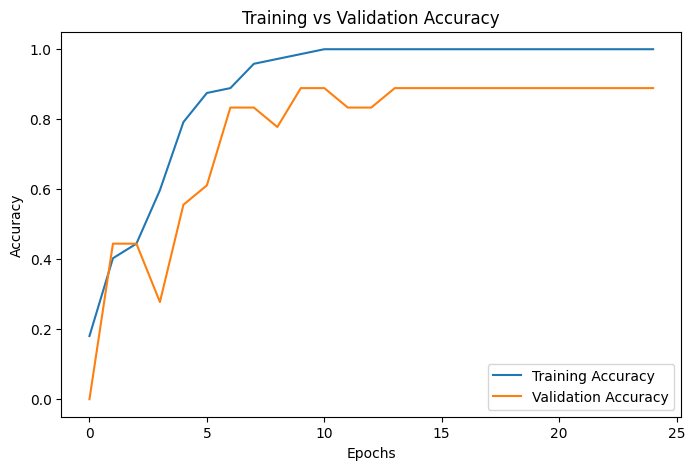

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

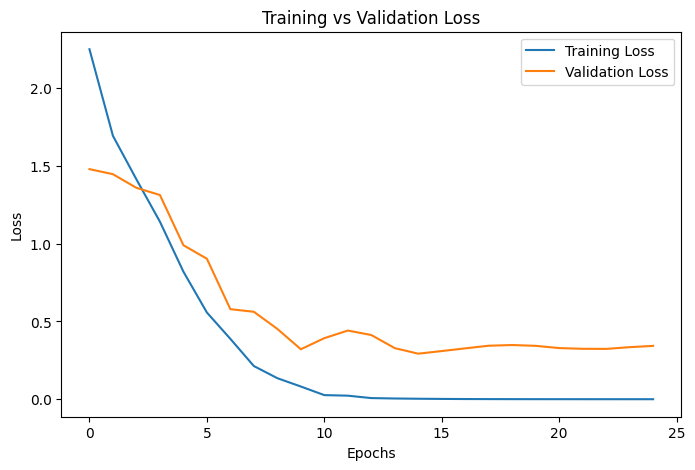

In [35]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

Task 8: Save and Load the Model

In [36]:
model.save("fruit_cnn_model.h5")
print("Model saved successfully")

Model saved successfully


In [37]:
loaded_model = tf.keras.models.load_model("fruit_cnn_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.6000 - loss: 1.0665
Loaded Model Test Loss: 1.0665347576141357
Loaded Model Test Accuracy: 0.6000000238418579


Task 9: Predictions and Classification Report

In [38]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.75      0.60      0.67         5
     cupuacu       0.67      0.80      0.73         5
    graviola       0.62      1.00      0.77         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.17      0.20      0.18         5

    accuracy                           0.60        30
   macro avg       0.66      0.60      0.60        30
weighted avg       0.66      0.60      0.60        30

